In [101]:
import json
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

In [160]:
#read json file
#Download the data from the statsbomb competition.json file.
# filter which tournament i want. and find the competition and season id of the tournament.
# using the ids load the tournament json file again 
# From there on load the match id for individual performance of a team or the whole performance and pattern of a team in the whole tournament
with open ('D:/football data/competitions.json', 'r', errors="ignore") as f:
    all= json.load(f)
df_all=pd.json_normalize(all, sep= '_')
df_all.head(3)


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431


In [163]:
print("all season we have right now:",df_all['season_name'].unique())
print("all competation we have right now:",df_all['competition_name'].unique())
#filter the competion
df_all[df_all['competition_name']=='UEFA Euro'] #Change the UEFA Euro

all season we have right now: <StringArray>
['2023/2024', '2015/2016',      '2023', '2018/2019', '2017/2018', '2016/2017',
 '2014/2015', '2013/2014', '2012/2013', '2011/2012', '2010/2011', '2009/2010',
 '2008/2009', '2006/2007', '2004/2005', '2003/2004', '1999/2000', '1972/1973',
 '1971/1972', '1970/1971',      '2024', '1983/1984', '1982/1983', '1977/1978',
 '2020/2021', '2019/2020',      '1979',      '2022',      '2018',      '1990',
      '1986',      '1974',      '1970',      '1962',      '1958', '2021/2022',
 '2007/2008', '2005/2006', '1973/1974', '1997/1998',      '1981', '2022/2023',
      '1977', '1986/1987',      '2020', '1988/1989',      '2025',      '2019']
Length: 48, dtype: str
all competation we have right now: <StringArray>
[          '1. Bundesliga',  'African Cup of Nations',
        'Champions League',            'Copa America',
            'Copa del Rey', 'FA Women's Super League',
      'FIFA U20 World Cup',          'FIFA World Cup',
       'Frauen Bundesliga',     

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
73,55,282,Europe,UEFA Euro,male,False,True,2024,2026-05-01T19:54:25.846072,2026-05-01T19:58:06.077979,2026-05-01T19:58:06.077979,2026-05-01T19:54:25.846072
74,55,43,Europe,UEFA Euro,male,False,True,2020,2026-05-10T12:59:26.302088,2026-05-10T13:00:25.564993,2026-05-10T13:00:25.564993,2026-05-10T12:59:26.302088


In [171]:
with open ('D:\\football data\\Euro 2024.json', 'r', errors="ignore") as k:
    euro= json.load(k)
df_competition=pd.json_normalize(euro, sep= '_')
#all team participating
df_competition['home_team_country_name'].unique()

<StringArray>
[      'Portugal',        'Hungary',         'Serbia',        'England',
        'Croatia',          'Spain',       'Slovenia',         'France',
         'Poland',        'Georgia',         'Turkey',        'Romania',
       'Slovakia',    'Switzerland',       'Scotland',    'Netherlands',
        'Denmark',        'Ukraine', 'Czech Republic',        'Austria',
        'Albania',        'Germany',        'Belgium',          'Italy']
Length: 24, dtype: str

In [174]:
#print("all of the euro column names:", df_euro.columns.to_numpy().tolist() )
pd.set_option('display.max_columns', None)
#filter the Country, change 'Germany' in the below df
df_filtered=df_competition[(df_competition['home_team_country_name'] == 'Germany') | (df_competition['away_team_country_name'] == 'Germany')]
print(df_filtered['competition_stage_name'].unique())
########################filter the competition#######################
df_filtered[df_filtered['competition_stage_name']=='Group Stage'] # Change the Group stage

<StringArray>
['Group Stage', 'Quarter-finals', 'Round of 16']
Length: 3, dtype: str


,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_competition_id,competition_country_name,competition_competition_name,season_season_id,season_season_name,home_team_home_team_id,home_team_home_team_name,home_team_home_team_gender,home_team_home_team_group,home_team_country_id,home_team_country_name,home_team_managers,away_team_away_team_id,away_team_away_team_name,away_team_away_team_gender,away_team_away_team_group,away_team_country_id,away_team_country_name,away_team_managers,metadata_data_version,metadata_shot_fidelity_version,metadata_xy_fidelity_version,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
19,3930176,2024-06-23,19:00:00.000,1,1,available,available,2026-05-01T19:54:25.846072,2026-05-01T19:58:06.077979,3,55,Europe,UEFA Euro,282,2024,773,Switzerland,male,None,221,Switzerland,"[{'id': 2832, 'name': 'Murat Yakin', 'nickname...",770,Germany,male,None,85,Germany,"[{'id': 445, 'name': 'Julian Nagelsmann', 'nic...",1.1.0,2,2,10,Group Stage,116458,Deutsche Bank Park,85,Germany,269,Daniele Orsato,112,Italy
44,3930168,2024-06-19,16:00:00.000,2,0,available,available,2026-05-01T19:46:44.244653,2026-05-01T19:52:50.304198,2,55,Europe,UEFA Euro,282,2024,770,Germany,male,None,85,Germany,"[{'id': 445, 'name': 'Julian Nagelsmann', 'nic...",916,Hungary,male,None,103,Hungary,"[{'id': 3616, 'name': 'Marco Rossi', 'nickname...",1.1.0,2,2,10,Group Stage,369,MHPArena,85,Germany,293,Danny Desmond Makkelie,160,Netherlands
50,3930158,2024-06-14,19:00:00.000,5,1,available,available,2026-05-01T19:43:49.048383,2026-05-01T19:44:28.668814,1,55,Europe,UEFA Euro,282,2024,770,Germany,male,None,85,Germany,"[{'id': 445, 'name': 'Julian Nagelsmann', 'nic...",942,Scotland,male,None,201,Scotland,"[{'id': 510, 'name': 'Steve Clarke', 'nickname...",1.1.0,2,2,10,Group Stage,4867,Allianz Arena,85,Germany,76,Clément Turpin,78,France


In [175]:
%config InlineBackend.figure_format = 'retina'
figsize = (9, 6)
from statsbombpy import sb
import mplsoccer as mpl
from kloppy import metrica
import matplotlib.pyplot as plt
from tqdm import tqdm

In [176]:
from matplotlib.colors import ListedColormap
def bulid_cmap(x, y):
    r,g,b = x
    r_, g_, b_ = y
    N = 256
    A = np.ones((N, 4))
    A[:, 0] = np.linspace(r, 1, N)
    A[:, 1] = np.linspace(g, 1, N)
    A[:, 2] = np.linspace(b, 1, N)
    cmp = ListedColormap(A)
    
    B = np.ones((N, 4))
    B[:, 0] = np.linspace(r_, 1, N)
    B[:, 1] = np.linspace(g_, 1, N)
    B[:, 2] = np.linspace(b_, 1, N)
    cmp_ = ListedColormap(B)
    
    newcolors = np.vstack((cmp(np.linspace(0, 1, 128)),
                            cmp_(np.linspace(1, 0, 128))))
    return ListedColormap(newcolors)

In [177]:
blue, red = (44,123,182), (215,25,28)
blue = [x/256 for x in blue]
red = [x/256 for x in red]
diverging = bulid_cmap(blue, red)
diverging_r = bulid_cmap(red, blue)

In [197]:
match=sb.events(match_id=	3930176)


In [198]:
print("all of the column names:", match.columns.to_numpy().tolist() )
match.head(3)

all of the column names: ['50_50', 'ball_receipt_outcome', 'ball_recovery_offensive', 'ball_recovery_recovery_failure', 'block_deflection', 'block_offensive', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_offensive', 'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'interception_outcome', 'location', 'match_id', 'minute', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_deflected', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_outcome', 'pass_ou

,50_50,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_type,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_replacement,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b7e7c3d5-b9ee-4cf4-bd60-b7812676261f,1,NaN,NaN,3930176,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Switzerland,773,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 3421, 'lineup': [{'player': {'id...",Switzerland,773,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ef6ba67d-1014-4005-a0ce-e8d27ebfaaec,2,NaN,NaN,3930176,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Switzerland,773,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Germany,770,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,adce90e2-b2a5-40c6-bad4-5b979407b6fb,3,NaN,NaN,3930176,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Switzerland,773,[7fd277fb-7059-4cb6-ae8f-46e863f4e56c],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Switzerland,773,00:00:00.000,Half Start,NaN


In [199]:
for i in match.columns:
    print(f'{i} : {list(match[i].drop_duplicates())}')

50_50 : [nan, {'outcome': {'id': 1, 'name': 'Lost'}}, {'outcome': {'id': 4, 'name': 'Won'}}]
ball_receipt_outcome : [nan, 'Incomplete']
ball_recovery_offensive : [nan, True]
ball_recovery_recovery_failure : [nan, True]
block_deflection : [nan, True]
block_offensive : [nan, True]
carry_end_location : [nan, [48.6, 36.4], [49.2, 46.9], [47.7, 35.8], [50.1, 13.9], [36.9, 20.3], [46.0, 5.7], [43.4, 16.0], [50.5, 16.6], [44.0, 26.9], [49.0, 32.6], [49.4, 58.4], [56.3, 55.0], [64.0, 74.6], [77.8, 76.9], [74.5, 76.4], [64.0, 78.4], [49.2, 70.2], [59.3, 76.4], [45.6, 65.1], [40.8, 55.6], [34.8, 39.2], [38.4, 8.4], [21.5, 23.8], [5.6, 40.7], [9.2, 65.8], [37.4, 79.4], [81.9, 61.5], [105.7, 48.1], [64.9, 67.6], [113.5, 69.9], [101.5, 64.7], [106.1, 60.0], [12.8, 16.2], [9.5, 17.2], [41.0, 16.4], [50.7, 32.4], [47.5, 22.3], [62.0, 22.1], [62.0, 57.6], [49.1, 47.0], [66.1, 75.8], [42.2, 2.8], [14.0, 29.5], [33.8, 70.8], [41.6, 76.2], [56.0, 76.2], [66.9, 5.9], [63.2, 4.4], [77.8, 19.0], [71.6, 25.9

In [182]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import numpy as np

def save_team_pass_maps(df, team, output_path):

    player_ids = df.loc[
        df['team'] == team,
        'player_id'
    ].dropna().unique()

    with PdfPages(output_path) as pdf:

        for player_id in player_ids:

            try:
                player = df[
                    (df['team'] == team) &
                    (df['player_id'] == player_id)
                ]['player'].unique().tolist()[0]

                passes = df[
                    (df['team'] == team) &
                    (df['type'] == "Pass") &
                    (df['player_id'] == player_id)
                ]

                x1, y1 = np.array(passes['location'].tolist()).T
                x2, y2 = np.array(passes['pass_end_location'].tolist()).T

                pitch = mpl.Pitch()
                fig, ax = pitch.draw(figsize=figsize)

                pitch.arrows(
                    x1, y1, x2, y2,
                    alpha=0.4,
                    color=blue,
                    headaxislength=3,
                    headlength=3,
                    headwidth=4,
                    width=2,
                    ax=ax
                )

                fig.suptitle(
                    f'{player} passes location and pass end location'
                )

                pdf.savefig(fig)
                plt.close(fig)

            except Exception as e:
                print(f"Skipping player {player_id}: {e}")

    print(f"PDF saved: {output_path}")

In [200]:
save_team_pass_maps(match,"Germany","D:/football data/german player passing.pdf" )

PDF saved: D:/football data/german player passing.pdf


In [184]:

def shots_by_country(df, country, figsize=(10, 7)):

    shots = df[
        (df['type'] == "Shot") &
        (df['team'] == country) &
        (df['shot_type'] != "Penalty")
    ]

    x, y = np.array(shots['location'].tolist()).T
    xg = shots['shot_statsbomb_xg'].to_numpy()

    colors = [
        'red' if outcome == "Goal" else 'black'
        for outcome in shots['shot_outcome']
    ]

    pitch = mpl.Pitch()
    fig, ax = pitch.draw(figsize=figsize)

    pitch.scatter(
        x,
        y,
        s=xg * 1000,
        c=colors,
        alpha=0.8,
        ax=ax
    )

    fig.suptitle(
        f'{country} Shots (Excluding Penalties)\n'
        'Red = Goal | Black = No Goal | Size = xG',
        fontsize=14
    )

    return fig, ax


(<Figure size 1000x700 with 1 Axes>, <Axes: >)
(<Figure size 1000x700 with 1 Axes>, <Axes: >)


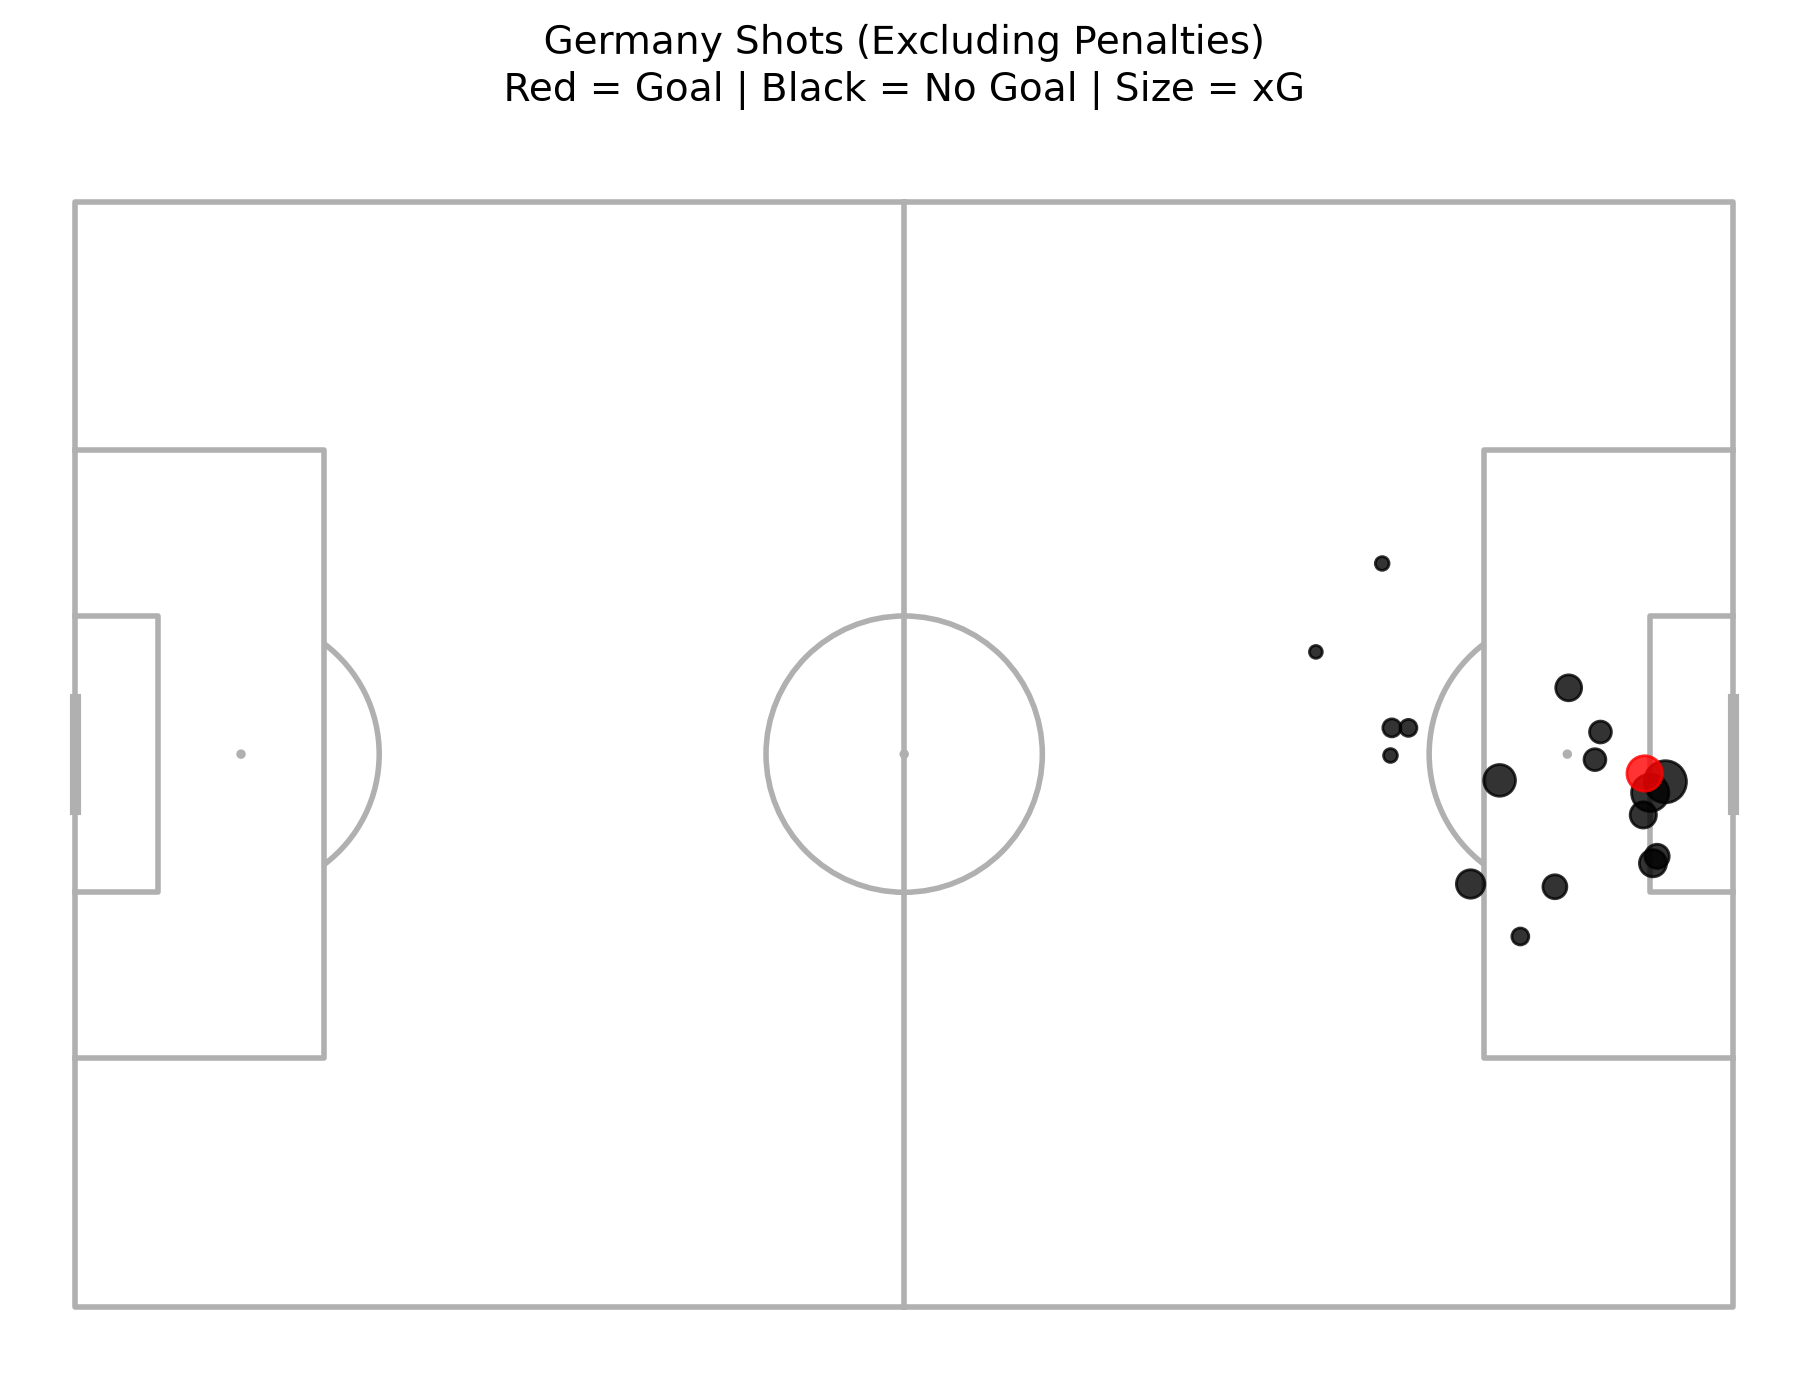

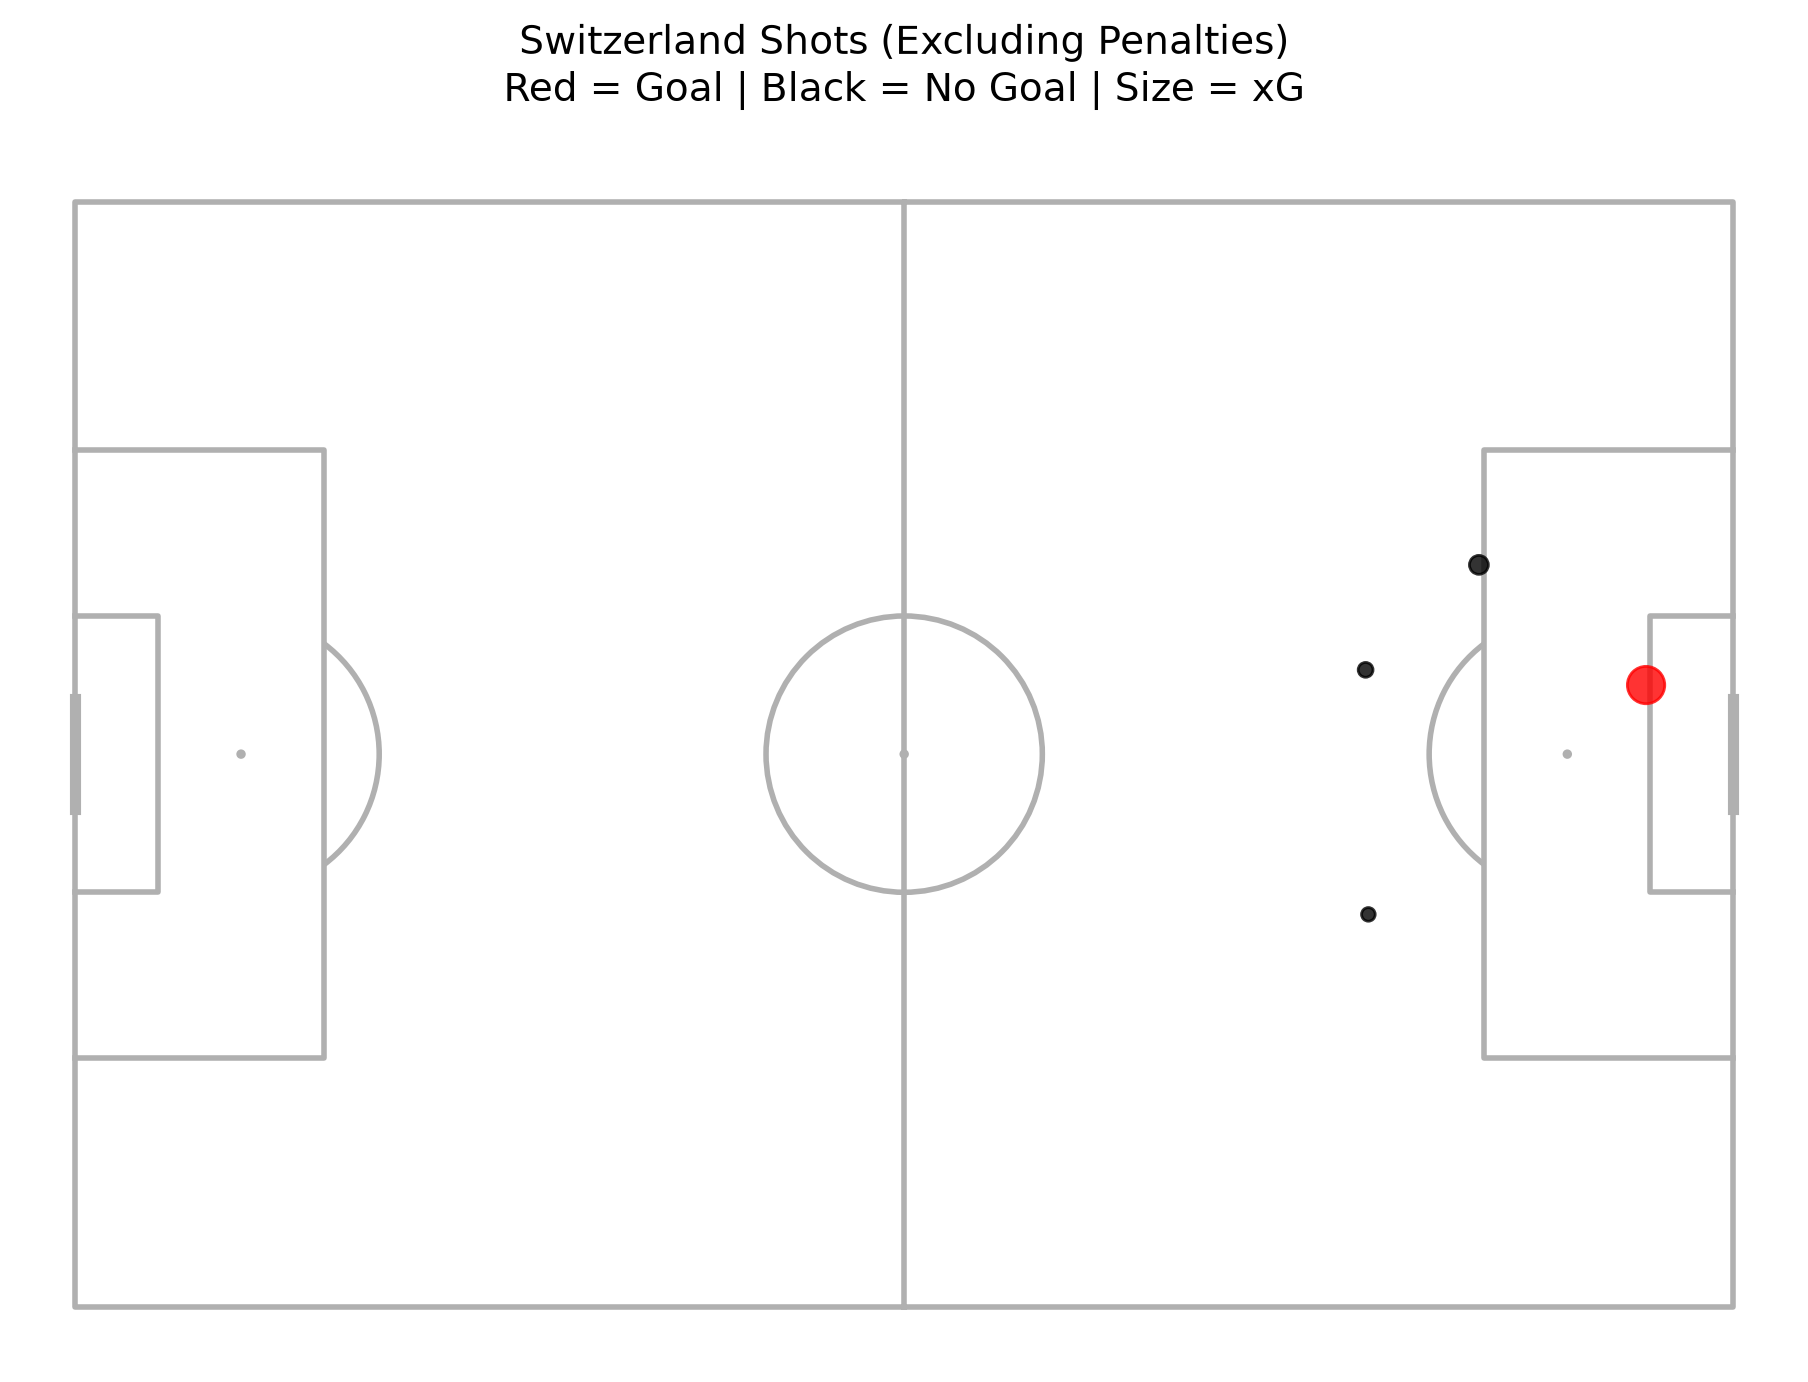

In [201]:
print(shots_by_country(match, country='Germany'))
print(shots_by_country(match, 'Switzerland'))

In [186]:
def heatmap_action(df, team_name):
    events = df[~pd.isna(df['location']) & 
                        (df['team'] == team_name)]
    x, y = np.array(events['location'].tolist()).T
    pitch = mpl.Pitch()
    fig, ax = pitch.draw(figsize=figsize)
    k = pitch.kdeplot(x, y, cmap='Blues', fill=True, levels=10, alpha=0.8, ax=ax)
    print(k)

Axes(0.125,0.11;0.775x0.77)


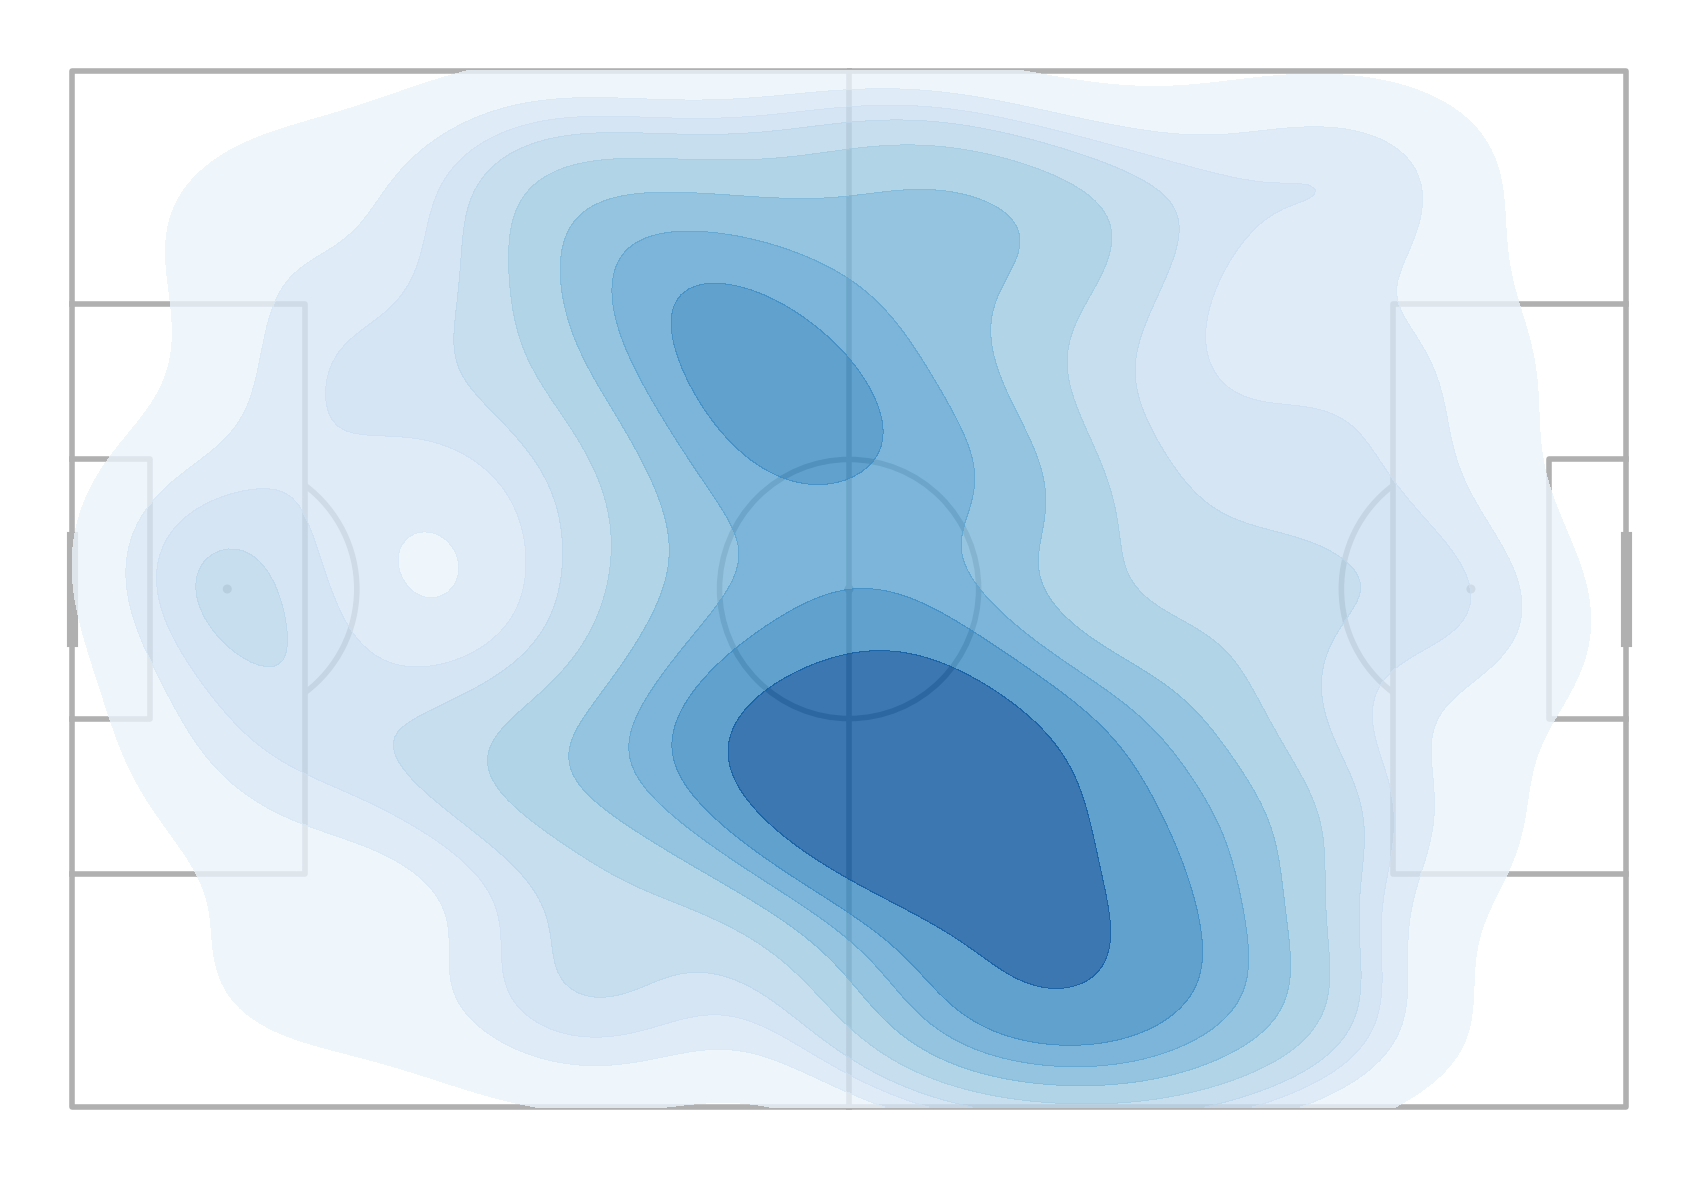

In [202]:
heatmap_action(match, "Germany")

In [188]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def save_player_heatmaps(df, team_name, output_path):

    player_ids = df.loc[
        df['team'] == team_name,
        'player_id'
    ].dropna().unique()

    with PdfPages(output_path) as pdf:

        for player_id in player_ids:

            try:
                player = df[
                    (df['team'] == team_name) &
                    (df['player_id'] == player_id)
                ]['player'].iloc[0]

                events = df[
                    (df['team'] == team_name) &
                    (df['player_id'] == player_id) &
                    (~pd.isna(df['location']))
                ]

                if len(events) == 0:
                    continue

                x, y = np.array(events['location'].tolist()).T

                pitch = mpl.Pitch()
                fig, ax = pitch.draw(figsize=figsize)

                pitch.kdeplot(
                    x, y,
                    cmap='Blues',
                    fill=True,
                    levels=10,
                    alpha=0.8,
                    ax=ax
                )

                fig.suptitle(
                    f'{player} Action Heatmap - {team_name}'
                )

                pdf.savefig(fig)
                plt.close(fig)

            except Exception as e:
                print(f"Skipping player {player_id}: {e}")

    print(f"PDF saved: {output_path}")

In [203]:
save_player_heatmaps(
    match,
    "Germany",
    r"D:/football data/germany_heatmaps.pdf"
)

PDF saved: D:/football data/germany_heatmaps.pdf


#### Overall pass clustering via k means for a single team

In [190]:
#collect all the match into the records dictionary \n
#in the orient use the file specification \n
#n matches= Number of match we want to consider \n
# Extract the Location and Pass end location - coordinates
# convert them to a dataframe and print the head of the dataframe

def get_team_passes(sb, competition_id, season_id, team_name, n_matches=None):
    """
    Retrieve pass coordinates for a given team.

    Returns a DataFrame with columns:
    x1, y1, x2, y2
    """

    matches = sb.matches(
        competition_id=competition_id,
        season_id=season_id
    ).to_dict(orient="records")

    team_matches = [
        m for m in matches
        if m["home_team"] == team_name
        or m["away_team"] == team_name
    ]

    if n_matches is not None:
        team_matches = team_matches[:n_matches]

    all_events = []

    for match in tqdm(team_matches, desc=team_name):
        events = sb.events(match_id=match["match_id"])

        passes = events[events["type"] == "Pass"][
            ["location", "pass_end_location"]
        ].dropna()

        for start, end in zip(
            passes["location"],
            passes["pass_end_location"]
        ):
            all_events.append([
                start[0], start[1],
                end[0], end[1]
            ])

    return pd.DataFrame(
        all_events,
        columns=["x1", "y1", "x2", "y2"]
    )

In [191]:
df= get_team_passes(
    sb,
    competition_id=55,
    season_id=282,
    team_name="Germany",
    n_matches=None
)

print(df.shape)

Germany: 100%|██████████| 5/5 [00:03<00:00,  1.43it/s]

(5461, 4)


Text(0.5, 0.98, 'Cluster of passes based on all matches in a tournamet for Germany')

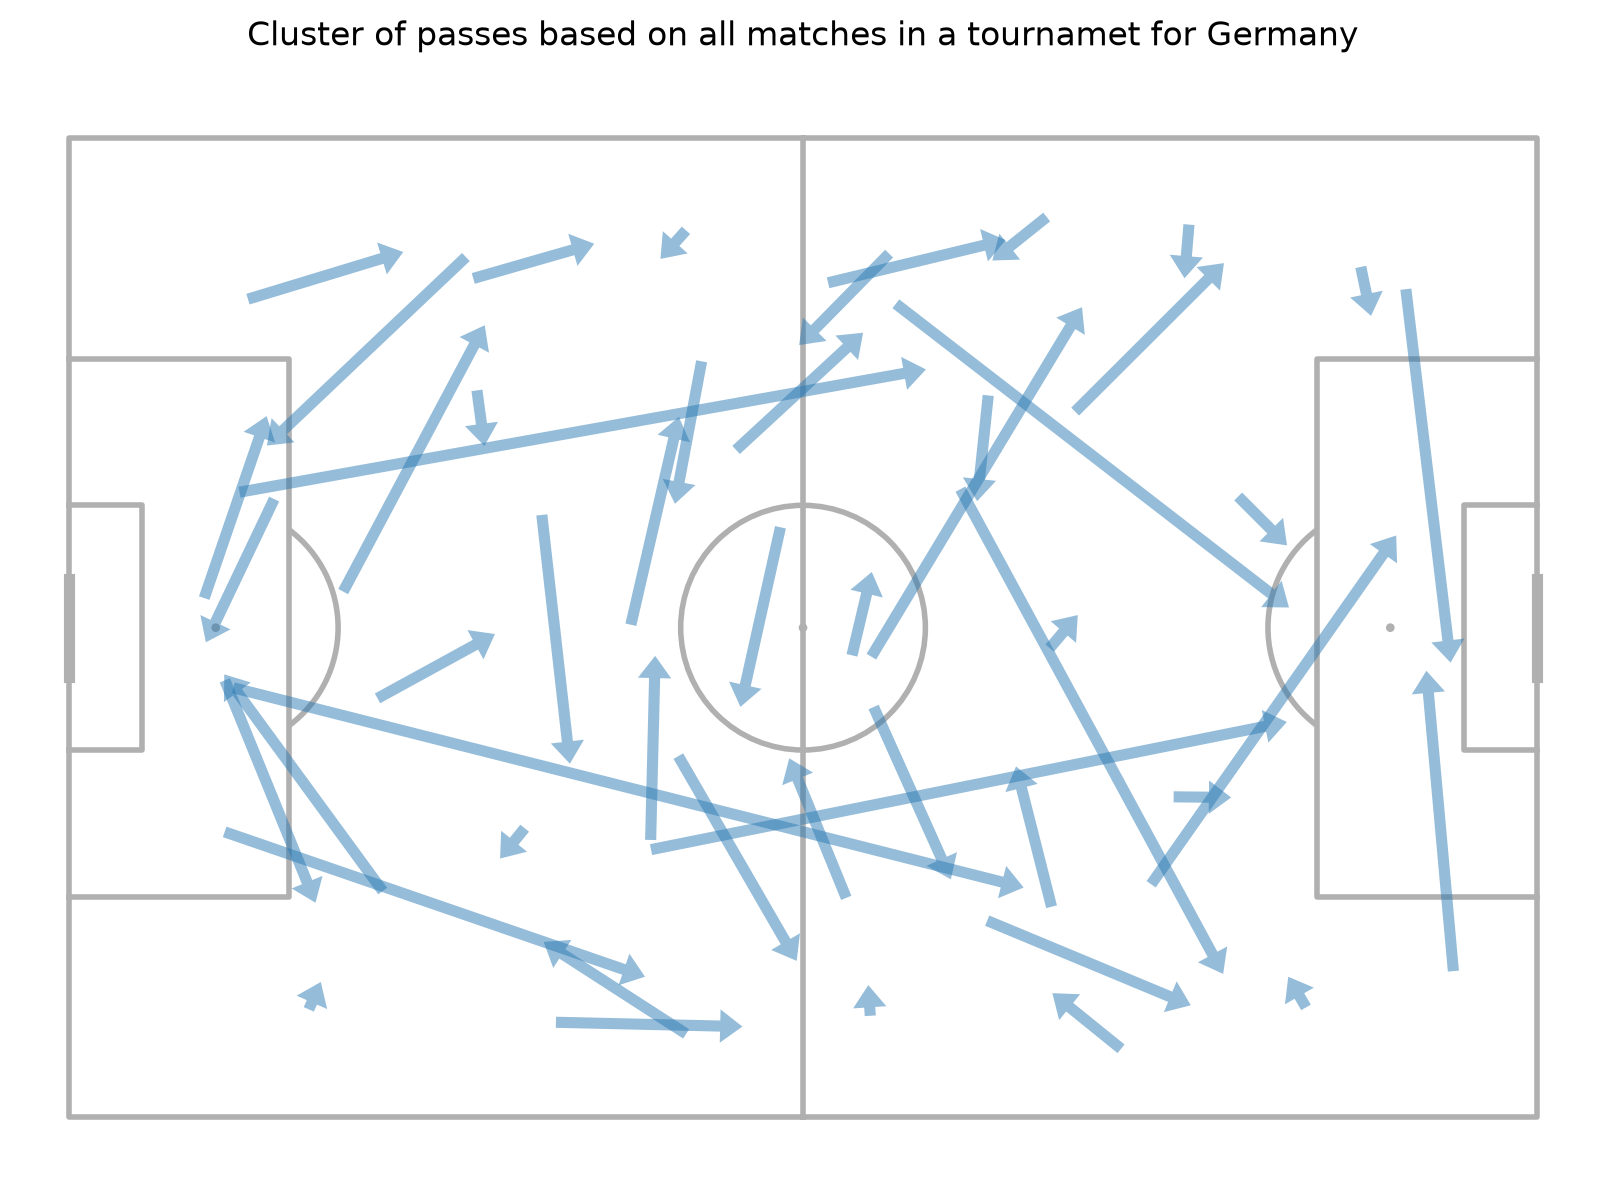

In [192]:
team='Germany'
####################################
model = KMeans(n_clusters=50)
features = df[['x1', 'y1', 'x2', 'y2']]
fit = model.fit(features)
pitch = mpl.Pitch()
fig, ax = pitch.draw(figsize=figsize)
for coords in fit.cluster_centers_:
  p = pitch.arrows(*coords, alpha=0.5, color=blue, ax=ax,
                   headaxislength=2, headlength=2, headwidth=3, width=4)
fig.suptitle(f'Cluster of passes based on all matches in a tournamet for {team}')

### A gentle remainder
x1,y1 is the pass start location &
and x2,y2 is the location where the pass ended up 

In [193]:
from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal


In [194]:
#Here we've decided to only use x2 and y2 attributes as they won't cluster around areas such as the 6-yard-box from goal kicks.
n_components = 40
gmm = GaussianMixture(n_components=n_components)
features = df[['x2', 'y2']]
fit = gmm.fit(features)
#Resampling from GMM
samples = gmm.sample(5000)

Text(0.5, 0.98, '5000 resampled data based one the pass ended up location')

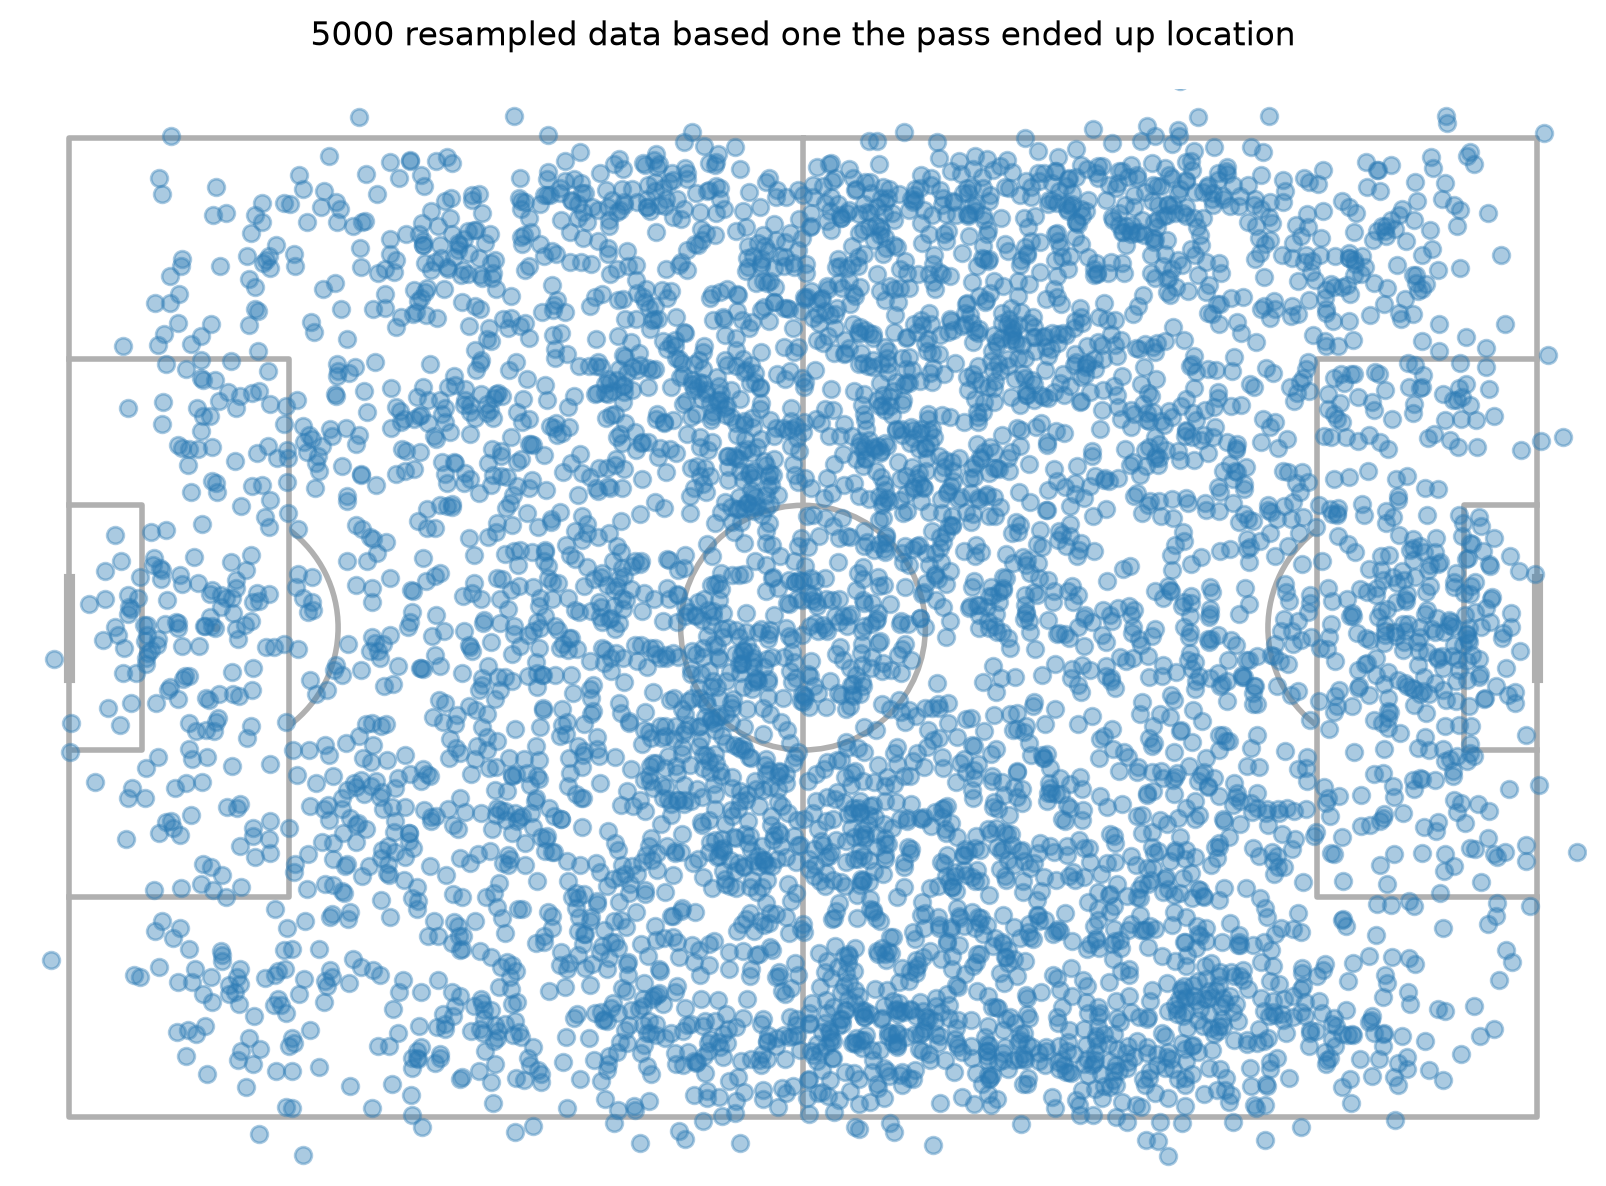

In [195]:
pitch = mpl.Pitch()
fig, ax = pitch.draw(figsize=figsize)
s = pitch.scatter(*samples[0].T, alpha=0.4, color=blue, ax=ax)
fig.suptitle('5000 resampled data based one the pass ended up location')

In [196]:
# calulate the multivariate normal pdf from the guassian mixture model.
x_min, x_max = 0, 120
y_min, y_max = 0, 80
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 120),
                     np.linspace(y_min, y_max, 80))

Z = np.zeros((xx.shape[0], xx.shape[1], n_components))
for i, (mean,
        covariance,
        weight) in enumerate(zip(gmm.means_,
                                 gmm.covariances_,
                                 gmm.weights_)):
          
    Z[:,:,i] = weight * multivariate_normal.pdf(
      np.column_stack([xx.ravel(), yy.ravel()]).reshape(
          xx.shape + (2,)), mean=mean, cov=covariance)

Z = Z.sum(axis=-1)
Z = Z.reshape(xx.shape)

Text(0.5, 0.98, 'The darker, more concentrated regions represent \n areas with the highest density of pass end-locations (x2, y2) \n for Germany')

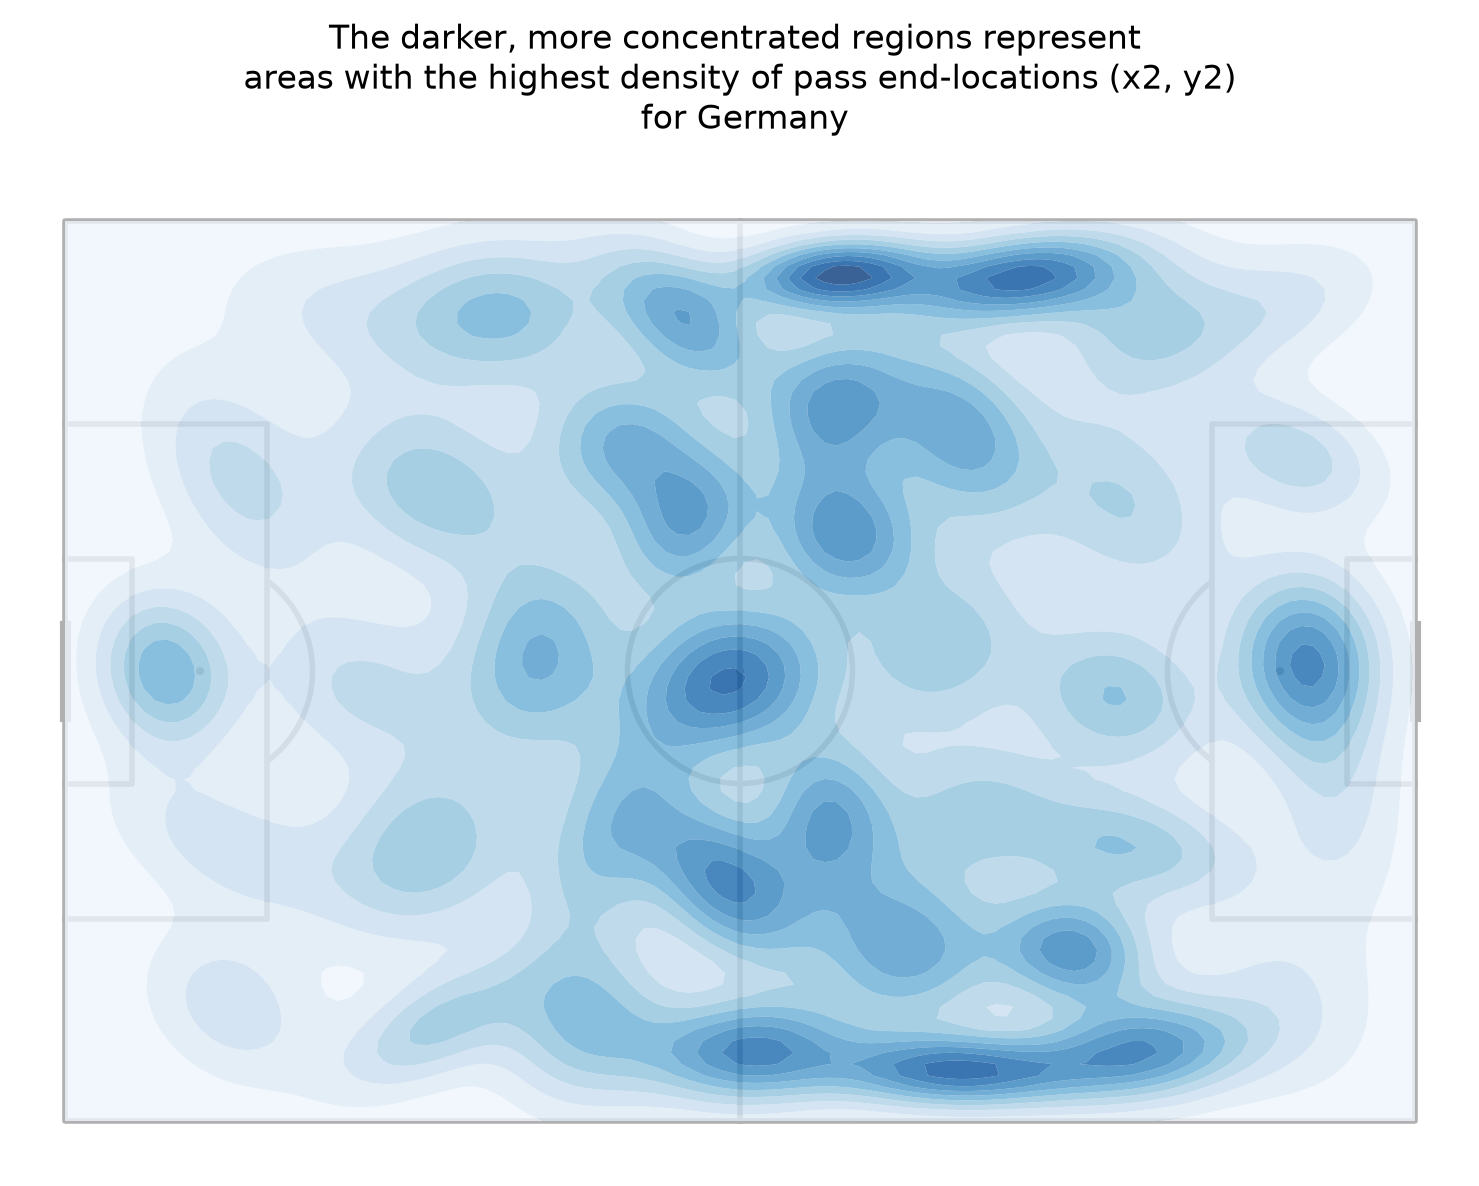

In [112]:
###########################
pitch = mpl.Pitch()
fig, ax = pitch.draw(figsize=figsize)
plot = ax.contourf(xx, yy, Z, levels=10,
                   cmap="Blues", alpha=0.8, antialiased=True)
fig.suptitle(f"The darker, more concentrated regions represent \n areas with the highest density of pass end-locations (x2, y2) \n for {team}")

### Model pass difficulty

In [95]:
def pass_difficulty_data(sb, competition_id, season_id, team_name, n_matches=None):
    """
    Retrieve pass coordinates for a given team.

    Returns a DataFrame with columns:
    x1, y1, x2, y2, output
    """

    matches = sb.matches(
        competition_id=competition_id,
        season_id=season_id
    ).to_dict(orient="records")

    team_matches = [
        m for m in matches
        if m["home_team"] == team_name
        or m["away_team"] == team_name
    ]

    if n_matches is not None:
        team_matches = team_matches[:n_matches]

    all_events = []
    
    for m in tqdm(team_matches, desc=team_name):
        events = sb.events(match_id = m['match_id'])
        passes = events[(events['type'] == "Pass")]
        x1, y1 = np.array(passes['location'].tolist()).T
        x2, y2 = np.array(passes['pass_end_location'].tolist()).T
        outcome = np.array(
            [1 if pd.isna(o) else 0 for o in passes['pass_outcome'].values]).T
        evs = np.vstack((x1, y1, x2, y2, outcome)).T
        all_events.extend(evs)
    df = pd.DataFrame(all_events, columns=['x1', 'y1', 'x2', 'y2', 'outcome'])
    return df

In [96]:
df= pass_difficulty_data(
    sb,
    competition_id=55,
    season_id=282,
    team_name="Germany",
    n_matches=None
)

Germany:   0%|          | 0/5 [00:00<?, ?it/s]

Germany: 100%|██████████| 5/5 [00:03<00:00,  1.40it/s]


In [97]:
X = df[['x1', 'y1', 'x2', 'y2']]
y = df['outcome']

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

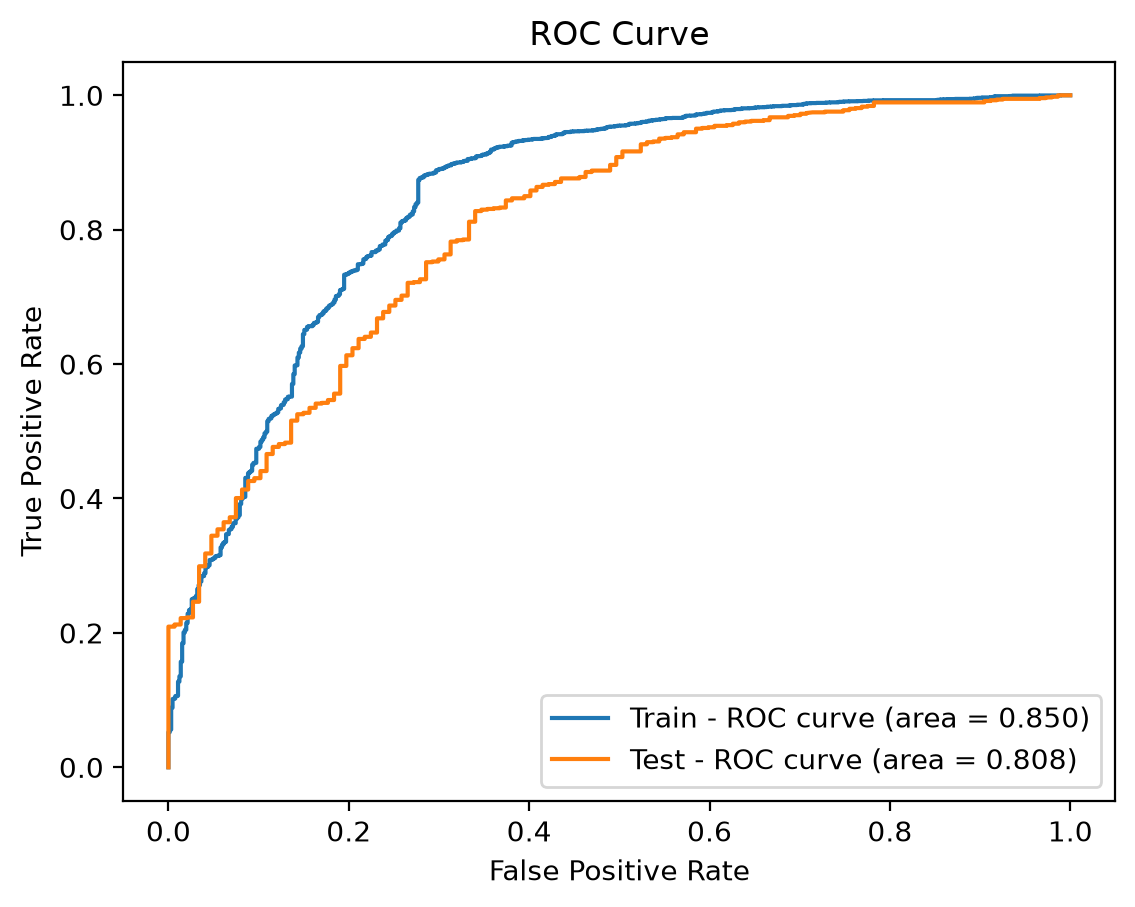

In [135]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

#model = HistGradientBoostingClassifier(learning_rate=0.01,max_depth=10,max_iter=50,random_state=0)
#model = xgb.XGBClassifier(random_state=0,n_jobs=-1)
#model = CatBoostClassifier(iterations=1000,learning_rate=0.03,depth=6,random_seed=0,verbose=0)
model = SVC(C=100,gamma='scale',probability=True,random_state=0)
#model = LogisticRegression(C=1.0,max_iter=5000,random_state=0)

fit = model.fit(X_train, y_train)
y_probs_train = model.predict_proba(X_train)[:, 1]
y_probs_test = model.predict_proba(X_test)[:, 1]
auc_train = roc_auc_score(y_train, y_probs_train)
auc_test = roc_auc_score(y_test, y_probs_test)
#Roc Curve
fpr, tpr, thresholds = roc_curve(y_train, y_probs_train)
fpr_, tpr_, thresholds_ = roc_curve(y_test, y_probs_test)

plt.plot(fpr, tpr, label='Train - ROC curve (area = {:.3f})'.format(auc_train))
plt.plot(fpr_, tpr_, label='Test - ROC curve (area = {:.3f})'.format(auc_test))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Text(0.5, 0.98, 'Blue: Pass completed with higher accuracy,\n Red: Pass completed with lower accuracy')

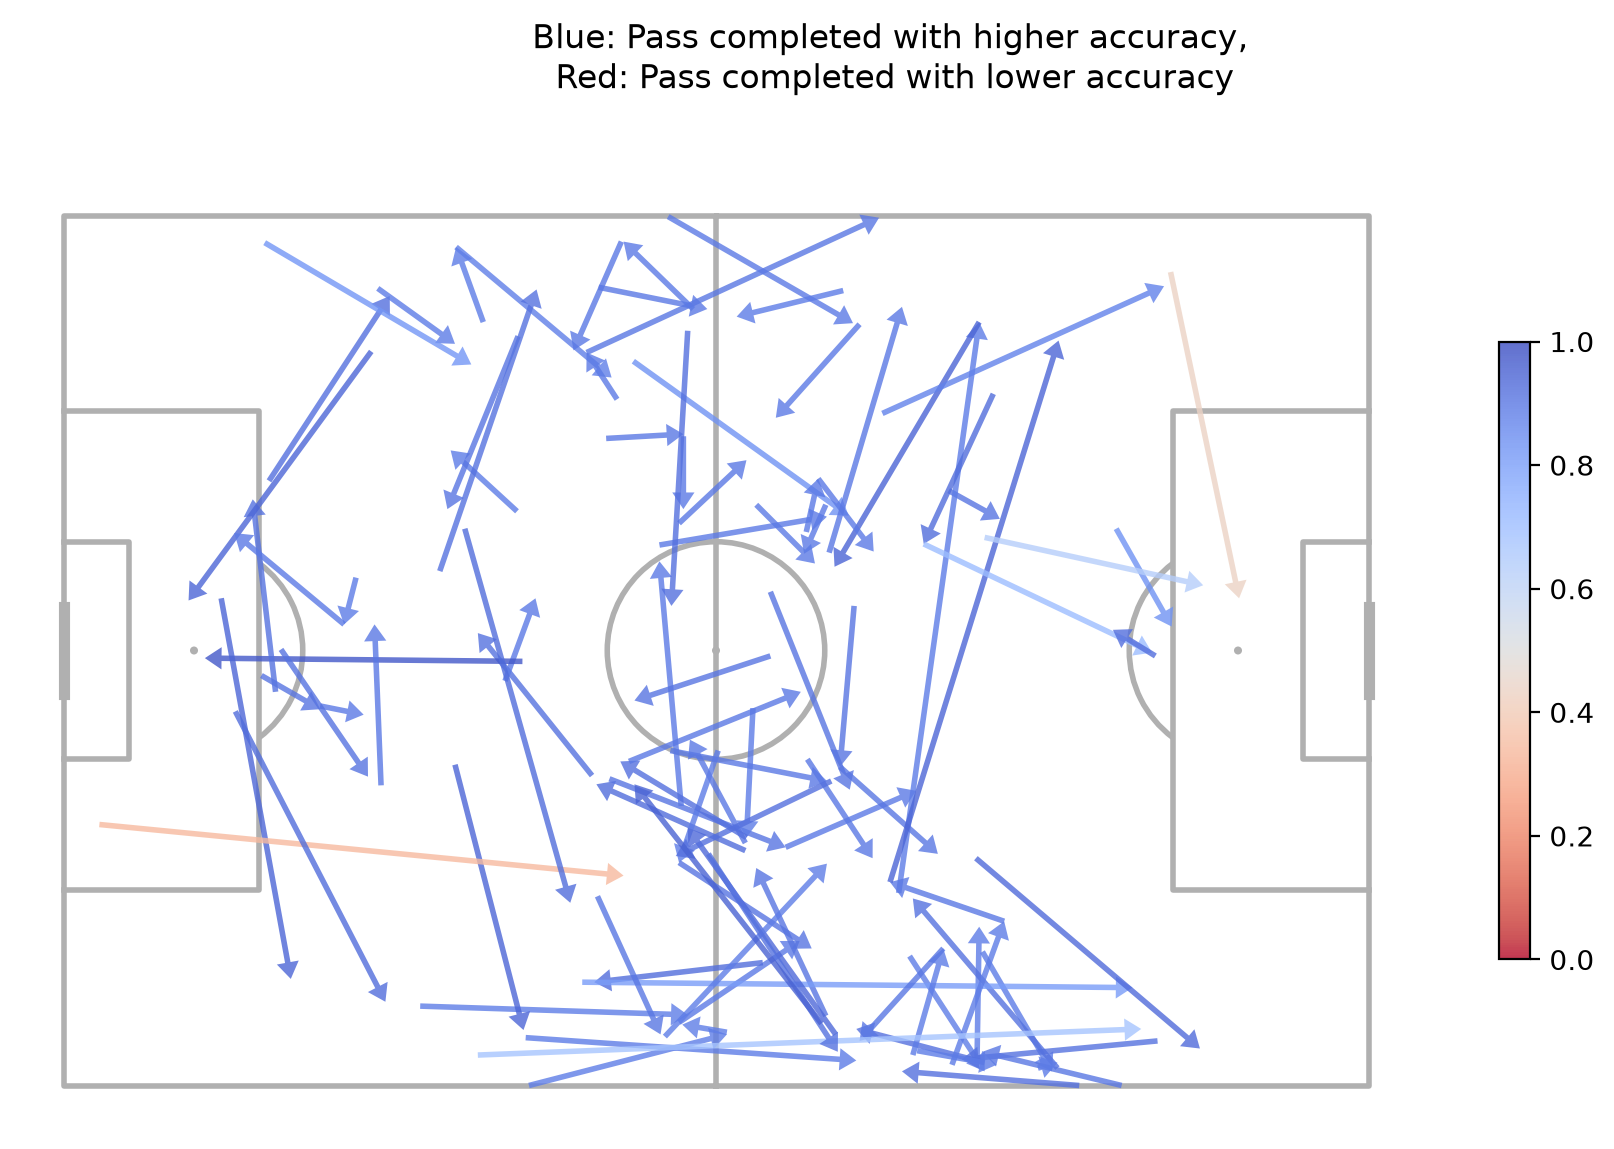

In [136]:
y_probs = model.predict_proba(df[['x1', 'y1', 'x2', 'y2']])[:, 1]
df['difficulty'] = y_probs
from matplotlib import colormaps as cm
cmap = cm['coolwarm_r']
coords = df[['x1', 'y1', 'x2', 'y2']].values[100:200].T
colors = cmap(df['difficulty'].values[100:200])
#This loads 100 pairs of coordinates and pass difficulties mapped to a color.
pitch = mpl.Pitch()
fig, ax = pitch.draw(figsize=figsize)
p = pitch.arrows(*coords, alpha=0.8, cmap='coolwarm_r', color=colors,
                  headaxislength=3, headlength=3, headwidth=4, width=2, ax=ax)
plt.colorbar(p, shrink=0.6)
fig.suptitle('Blue: Pass completed with higher accuracy,\n Red: Pass completed with lower accuracy')